# Lasso SELECTION

In [20]:
# ==============================================================================
# [CELL 1] AGGREGATE PCL - BULLETPROOF PARSING & RESIDUAL MODELING
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm
import os

try:
    from pmdarima import auto_arima
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False

PD_VER = int(pd.__version__.split(".")[0])
Q_FREQ = "QE" if PD_VER >= 2 else "Q"

print(">>> [Cell 1] Loading dataset, applying robust accounting fixes, and building feature pool...")

# 1. Parse accounting negative formats (e.g., "(150)" -> -150.0)
def clean_num(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float)): return float(x)
    s = str(x).strip().replace(",", "").replace("$", "").replace(" ", "")
    if s in ["—", "", "-", "NA", "N/A", "nan", "NaN"]: return np.nan
    if s.startswith("(") and s.endswith(")"):
        s = "-" + s[1:-1]
    try: return float(s)
    except Exception: return np.nan

file_hist = "Complete_UC2_Forecast_Data.xlsx"
raw_df = pd.read_excel(file_hist, sheet_name="Forecast Data", header=1)

cols_to_clean = ["PCL_t+1", "PCL_t", "BBG_Fcst_for_PCL_t+1", 
                 "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1", "Unemp_1_month_prior _to_t+1", 
                 "Rfsh_Fcst_BoC_1_month_prior_to_t+1", "Sent_BART_t", "GDP_YoY_t", "Overnight_Rate_t"]

for c in cols_to_clean:
    if c in raw_df.columns: raw_df[c] = raw_df[c].apply(clean_num)

# 2. Fill missing macro data per bank to prevent dropping years
raw_df = raw_df.sort_values(by=["Bank", "Year", "Quarter"])
cols_to_fill = ["PCL_t", "BBG_Fcst_for_PCL_t+1", "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1", "Unemp_1_month_prior _to_t+1", "Rfsh_Fcst_BoC_1_month_prior_to_t+1", "Sent_BART_t"]
for c in cols_to_fill:
    if c in raw_df.columns: 
        raw_df[c] = raw_df.groupby("Bank")[c].transform(lambda x: x.ffill().bfill())

# 3. Aggregate 5 banks safely
def sum_safe(x): return x.sum(min_count=1)

agg_funcs = {
    "PCL_t+1": sum_safe, "PCL_t": sum_safe, "BBG_Fcst_for_PCL_t+1": sum_safe,
    "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1": "mean", "Unemp_1_month_prior _to_t+1": "mean",
    "Rfsh_Fcst_BoC_1_month_prior_to_t+1": "mean", "Sent_BART_t": "mean", 
    "GDP_YoY_t": "mean", "Overnight_Rate_t": "mean"
}
agg_funcs = {k: v for k, v in agg_funcs.items() if k in raw_df.columns}

agg_df = raw_df.groupby(["Year", "Quarter"], as_index=False).agg(agg_funcs)
q_map = {"Q1": "03-31", "Q2": "06-30", "Q3": "09-30", "Q4": "12-31"}
agg_df.index = pd.DatetimeIndex(agg_df["Year"].fillna(0).astype(int).astype(str) + "-" + agg_df["Quarter"].map(q_map))
agg_df = agg_df.sort_index().asfreq(Q_FREQ)

agg_df = agg_df[agg_df.index <= "2026-03-31"]

# 4. Target: Predicting the Delta against Bloomberg
agg_df["PCL_Residual_t+1"] = agg_df["PCL_t+1"] - agg_df["BBG_Fcst_for_PCL_t+1"]

# 5. Define the Candidate Pool for Lasso to pick from
agg_df["CloseIn_GDP"] = agg_df["Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1"]
agg_df["BART_x_CloseIn_Unemp"] = agg_df["Sent_BART_t"] * agg_df["Unemp_1_month_prior _to_t+1"]
agg_df["BART_x_CloseIn_BoC"] = agg_df["Sent_BART_t"] * agg_df["Rfsh_Fcst_BoC_1_month_prior_to_t+1"]
agg_df["BART_x_CloseIn_GDP"] = agg_df["Sent_BART_t"] * agg_df["CloseIn_GDP"]

candidate_features = [
    "CloseIn_GDP", "Unemp_1_month_prior _to_t+1", "Rfsh_Fcst_BoC_1_month_prior_to_t+1",
    "Sent_BART_t", "BART_x_CloseIn_Unemp", "BART_x_CloseIn_BoC", "BART_x_CloseIn_GDP"
]
features_ts_hist = ["GDP_YoY_t", "Overnight_Rate_t"] 

# Create the final base dataframe
model_df = agg_df[["PCL_t+1", "PCL_t", "BBG_Fcst_for_PCL_t+1", "PCL_Residual_t+1", "Year", "Quarter"] + candidate_features + features_ts_hist].copy()

print(f"✅ Cell 1 Complete! Candidate pool ready. 2026 Q1 Actual PCL_t: ${model_df['PCL_t'].dropna().iloc[-1]:,.0f}M")

>>> [Cell 1] Loading dataset, applying robust accounting fixes, and building feature pool...
✅ Cell 1 Complete! Candidate pool ready. 2026 Q1 Actual PCL_t: $4,619M



>>> [Cell 2&3] Lasso is selecting features, followed by 8-Model Showdown...

🔍 STEP 1: DYNAMIC FEATURE SELECTION RESULTS (PREDICTING DELTA)
  ✅ KEPT     : CloseIn_GDP                         (Residual Weight:  -775.68)
  ✅ KEPT     : Unemp_1_month_prior _to_t+1         (Residual Weight:  -210.18)
  ❌ PRUNED   : Rfsh_Fcst_BoC_1_month_prior_to_t+1  (Residual Weight:     0.00)
  ✅ KEPT     : Sent_BART_t                         (Residual Weight:   219.98)
  ❌ PRUNED   : BART_x_CloseIn_Unemp                (Residual Weight:    -0.00)
  ✅ KEPT     : BART_x_CloseIn_BoC                  (Residual Weight:   260.04)
  ❌ PRUNED   : BART_x_CloseIn_GDP                  (Residual Weight:    -0.00)

📘 TABLE 1: PERFORMANCE IMPROVEMENT (Strict Rolling OOS)


Metric,08. ML: Gradient Boosting,BBG Raw Baseline,Improvement
OOS R²,0.6175,0.6102,+0.0073
OOS MAPE (%),5.6832,5.1390,+0.5442
OOS RMSE ($M),322.8028,325.8493,-3.0465



🔍 TABLE 2: COEFFICIENTS & P-VALUES FOR SURVIVOR FEATURES


Variable,Lasso β,OLS p-value,Status
CloseIn_GDP,-775.6838,0.000000,Active
Unemp_1_month_prior _to_t+1,-210.1779,0.275973,Active
Sent_BART_t,+219.9817,0.051012,Active
BART_x_CloseIn_BoC,+260.0428,0.054927,Active



🎯 UNIFIED 8-MODEL SCORECARD


Model,OOS R2,OOS MAPE,OOS RMSE
02. Baseline: Bloomberg Consensus,0.6102,5.14%,325.8
08. ML: Gradient Boosting,0.6175,5.68%,322.8
07. ML: Random Forest,0.4574,6.80%,384.5
05. ML: Lasso,0.5333,7.08%,356.5
06. ML: Ridge,0.5071,7.52%,366.4
03. TimeSeries: SARIMA,0.1660,7.72%,476.6
04. TimeSeries: VAR,0.1214,8.25%,489.2
01. Baseline: Naive (Last Qtr),-1.1770,14.52%,770.1


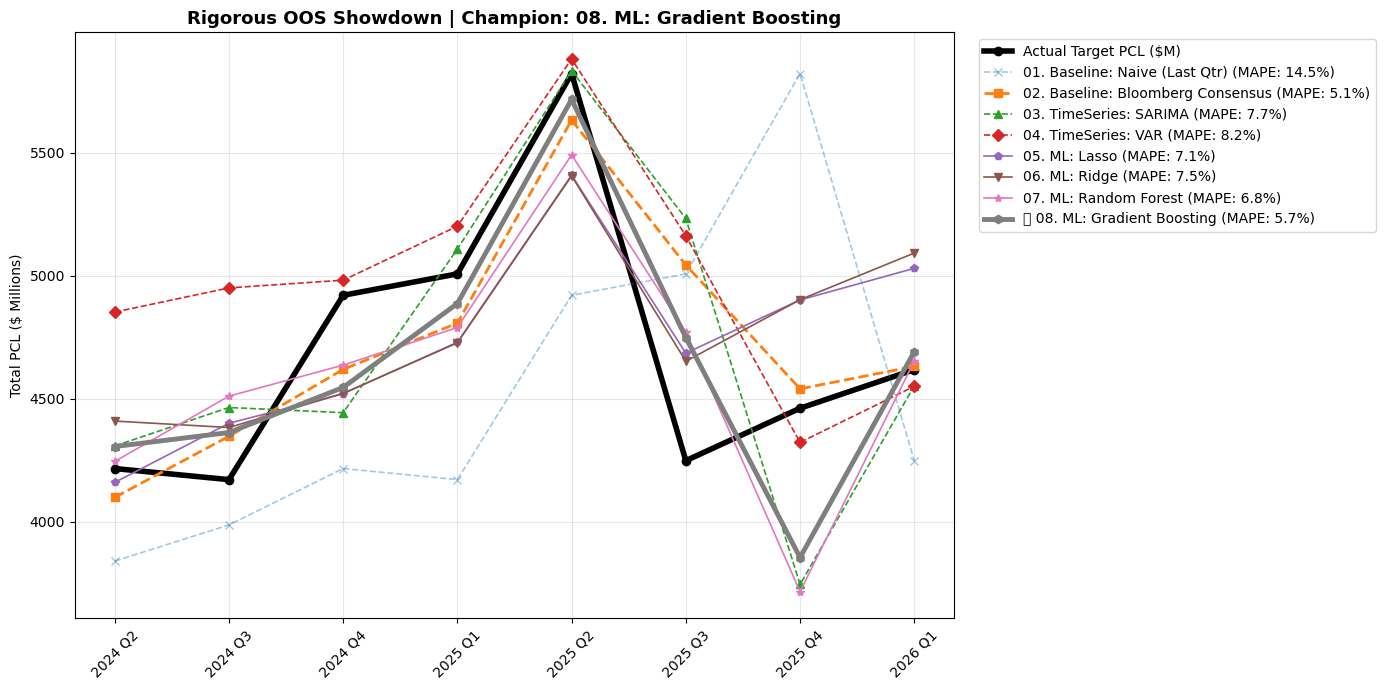

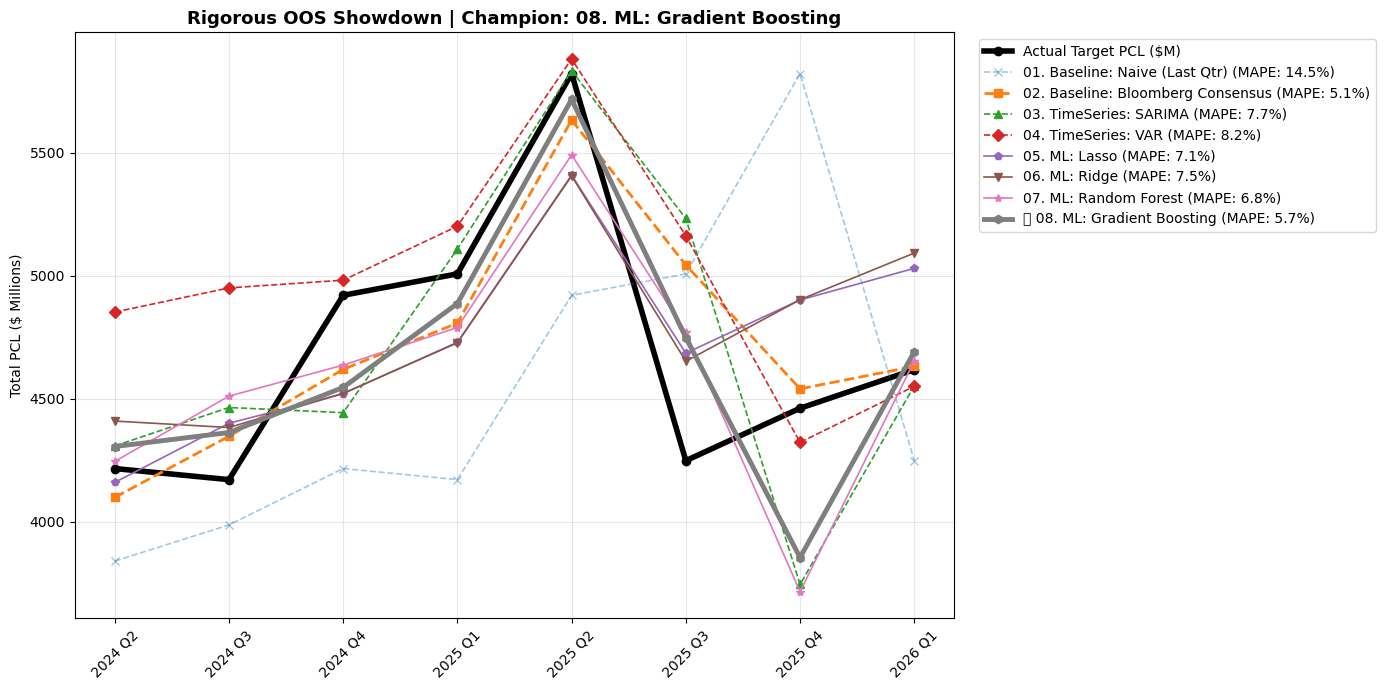

In [21]:
# ==============================================================================
# [CELL 2&3] DYNAMIC FEATURE SELECTION & ROLLING OOS BACKTEST
# ==============================================================================
print(f"\n>>> [Cell 2&3] Lasso is selecting features, followed by 8-Model Showdown...\n")

# Isolate valid training set for the residual target
train_valid_df = model_df.dropna(subset=["PCL_Residual_t+1"]).copy()

# ==============================================================================
# 🎯 PIPELINE STEP 1: LASSO CV FEATURE SELECTION
# ==============================================================================
tscv_fs = TimeSeriesSplit(n_splits=3)
X_cand_sc = StandardScaler().fit_transform(train_valid_df[candidate_features])
y_resid = train_valid_df["PCL_Residual_t+1"].values

lasso_fs = LassoCV(alphas=np.logspace(-2, 4, 50), cv=tscv_fs, random_state=42).fit(X_cand_sc, y_resid)

# PIPELINE LINKAGE: These selected features are strictly passed downstream!
selected_features_ml = []
print("="*85)
print("🔍 STEP 1: DYNAMIC FEATURE SELECTION RESULTS (PREDICTING DELTA)")
print("="*85)
for feat, coef in zip(candidate_features, lasso_fs.coef_):
    status = "✅ KEPT" if abs(coef) > 1e-4 else "❌ PRUNED"
    if abs(coef) > 1e-4: selected_features_ml.append(feat)
    print(f"  {status:10s} : {feat:35s} (Residual Weight: {coef:>8.2f})")

if not selected_features_ml: 
    print("⚠️ Fallback activated: Lasso retained 'CloseIn_GDP'.")
    selected_features_ml = ["CloseIn_GDP"]

# ==============================================================================
# 🎯 PIPELINE STEP 2: 8-MODEL ROLLING OOS (USING ONLY SELECTED FEATURES)
# ==============================================================================
tscv = TimeSeriesSplit(n_splits=3)
ml_models_dict = {
    "05. ML: Lasso": LassoCV(alphas=np.logspace(-2, 4, 50), cv=tscv),
    "06. ML: Ridge": RidgeCV(alphas=np.logspace(-2, 4, 50), cv=tscv),
    "07. ML: Random Forest": RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    "08. ML: Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)
}

h_test = 8  
test_indices = list(range(len(train_valid_df) - h_test, len(train_valid_df)))
prediction_records = []

for t in test_indices:
    if t < 12: continue
    train_df, test_row = train_valid_df.iloc[:t], train_valid_df.iloc[t:t+1]
    
    y_tr_resid = train_df["PCL_Residual_t+1"]
    y_actual = float(test_row["PCL_t+1"].iloc[0])
    bbg_base_pred = float(test_row["BBG_Fcst_for_PCL_t+1"].iloc[0])
    
    yr, qtr = int(test_row.index[0].year), f"Q{test_row.index[0].quarter + 1}" if test_row.index[0].quarter < 4 else f"Q1"
    if qtr == "Q1": yr += 1

    def eval_mod(m_name, p_val): 
        prediction_records.append({'Year': yr, 'Quarter': qtr, 'Model': m_name, 'Predicted ($M)': float(np.squeeze(p_val)), 'Actual ($M)': y_actual})
    
    eval_mod("01. Baseline: Naive (Last Qtr)", train_df["PCL_t"].iloc[-1])
    eval_mod("02. Baseline: Bloomberg Consensus", bbg_base_pred)
    
    try:
        if HAS_PMDARIMA: 
            sar_p = auto_arima(y_tr_resid, X=train_df[features_ts_hist], seasonal=False, suppress_warnings=True).predict(n_periods=1, X=test_row[features_ts_hist])[0]
        else: 
            sar_p = ARIMA(y_tr_resid.values, exog=train_df[features_ts_hist].values, order=(1,0,0)).fit().forecast(steps=1, exog=test_row[features_ts_hist].values)[0]
        eval_mod("03. TimeSeries: SARIMA", bbg_base_pred + sar_p)
    except: 
        eval_mod("03. TimeSeries: SARIMA", bbg_base_pred + y_tr_resid.iloc[-1])

    try: 
        var_p = VAR(train_df[["PCL_Residual_t+1"] + features_ts_hist]).fit(maxlags=1).forecast(train_df[["PCL_Residual_t+1"] + features_ts_hist].values[-1:], steps=1)[0, 0]
        eval_mod("04. TimeSeries: VAR", bbg_base_pred + var_p)
    except: 
        eval_mod("04. TimeSeries: VAR", bbg_base_pred + y_tr_resid.iloc[-1])

    # 🌟 PIPELINE LINKAGE: Strictly transforming data using selected_features_ml
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(train_df[selected_features_ml])
    X_te_sc = sc.transform(test_row[selected_features_ml])
    
    for m_name, model in ml_models_dict.items():
        ml_resid = model.fit(X_tr_sc, y_tr_resid).predict(X_te_sc)[0]
        eval_mod(m_name, bbg_base_pred + ml_resid)

results_df = pd.DataFrame(prediction_records)
metrics_list = []
for model_name, grp in results_df.groupby("Model"):
    valid = grp.dropna(subset=["Predicted ($M)", "Actual ($M)"])
    if len(valid) > 0:
        y_a, y_p = valid["Actual ($M)"].values.astype(float), valid["Predicted ($M)"].values.astype(float)
        metrics_list.append({"Model": model_name, "OOS R2": r2_score(y_a, y_p), "OOS MAPE": float(np.mean(np.abs((y_a - y_p) / np.abs(y_a)))) * 100, "OOS RMSE": float(np.sqrt(np.mean((y_a - y_p)**2)))})

final_table = pd.DataFrame(metrics_list).sort_values(by="OOS MAPE").reset_index(drop=True)
best_ml_model_name = final_table[final_table["Model"].str.contains("ML:")]["Model"].iloc[0]
best_rmse = final_table[final_table["Model"].str.contains("ML:")]["OOS RMSE"].iloc[0]

# ==============================================================================
# 🎯 PROCESS 3: ACADEMIC TABLES & SCORECARD
# ==============================================================================
bbg_stats = final_table[final_table["Model"] == "02. Baseline: Bloomberg Consensus"].iloc[0]
champ_stats = final_table[final_table["Model"] == best_ml_model_name].iloc[0]

table_1 = pd.DataFrame({
    "Metric": ["OOS R²", "OOS MAPE (%)", "OOS RMSE ($M)"],
    f"{best_ml_model_name}": [champ_stats["OOS R2"], champ_stats["OOS MAPE"], champ_stats["OOS RMSE"]],
    "BBG Raw Baseline": [bbg_stats["OOS R2"], bbg_stats["OOS MAPE"], bbg_stats["OOS RMSE"]]
})
table_1["Improvement"] = table_1[f"{best_ml_model_name}"] - table_1["BBG Raw Baseline"]

X_surv_sc = StandardScaler().fit_transform(train_valid_df[selected_features_ml])
ols_model = sm.OLS(y_resid, sm.add_constant(X_surv_sc)).fit()
coef_list = [{"Variable": feat, "Lasso β": lasso_fs.coef_[candidate_features.index(feat)], "OLS p-value": pval, "Status": "Active"} for feat, pval in zip(selected_features_ml, ols_model.pvalues[1:])]

print("\n" + "="*85)
print(f"📘 TABLE 1: PERFORMANCE IMPROVEMENT (Strict Rolling OOS)")
print("="*85)
display(table_1.style.format({f"{best_ml_model_name}": "{:.4f}", "BBG Raw Baseline": "{:.4f}", "Improvement": "{:+.4f}"}).set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis="index"))

print("\n" + "="*85)
print(f"🔍 TABLE 2: COEFFICIENTS & P-VALUES FOR SURVIVOR FEATURES")
print("="*85)
display(pd.DataFrame(coef_list).style.format({"Lasso β": "{:+.4f}", "OLS p-value": "{:.6f}"}).set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis="index"))

print("\n" + "="*85)
print("🎯 UNIFIED 8-MODEL SCORECARD")
print("="*85)
display(final_table.style.format({"OOS R2": "{:.4f}", "OOS MAPE": "{:.2f}%", "OOS RMSE": "{:.1f}"}).set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis="index").background_gradient(subset=['OOS MAPE'], cmap='Blues'))

plt.close('all'); fig_sd, ax_sd = plt.subplots(figsize=(14, 7))
detail_df = results_df[results_df["Model"] == best_ml_model_name]
time_labels = [f"{y} {q}" for y, q in zip(detail_df["Year"], detail_df["Quarter"])]
x_ticks_sd = np.arange(len(time_labels))

ax_sd.plot(x_ticks_sd, detail_df["Actual ($M)"].values, 'k-o', label="Actual Target PCL ($M)", linewidth=4.0)

colors, markers = sns.color_palette("tab10", len(metrics_list)), ['x', 's', '^', 'D', 'p', 'v', '*', 'h']
for i, m_name in enumerate(sorted(final_table["Model"])):
    m_data = results_df[results_df["Model"] == m_name]
    lw = 3.5 if m_name == best_ml_model_name else (2.0 if 'Bloomberg' in m_name else 1.2)
    ax_sd.plot(x_ticks_sd, m_data["Predicted ($M)"].values, linestyle='--' if 'Baseline' in m_name or 'TimeSeries' in m_name else '-', marker=markers[i%len(markers)], color=colors[i], label=f"{'🏆 ' if m_name == best_ml_model_name else ''}{m_name} (MAPE: {final_table[final_table['Model'] == m_name]['OOS MAPE'].iloc[0]:.1f}%)", linewidth=lw, alpha=0.4 if 'Naive' in m_name else 1.0)

ax_sd.set_xticks(x_ticks_sd)
ax_sd.set_xticklabels(time_labels, rotation=45)
ax_sd.set_title(f"Rigorous OOS Showdown | Champion: {best_ml_model_name}", fontweight="bold", fontsize=13); ax_sd.set_ylabel("Total PCL ($ Millions)"); ax_sd.grid(True, alpha=0.3); ax_sd.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout(); display(fig_sd)

>>> [Cell 4] Deploying 08. ML: Gradient Boosting with COVID Historical Playback Logic...


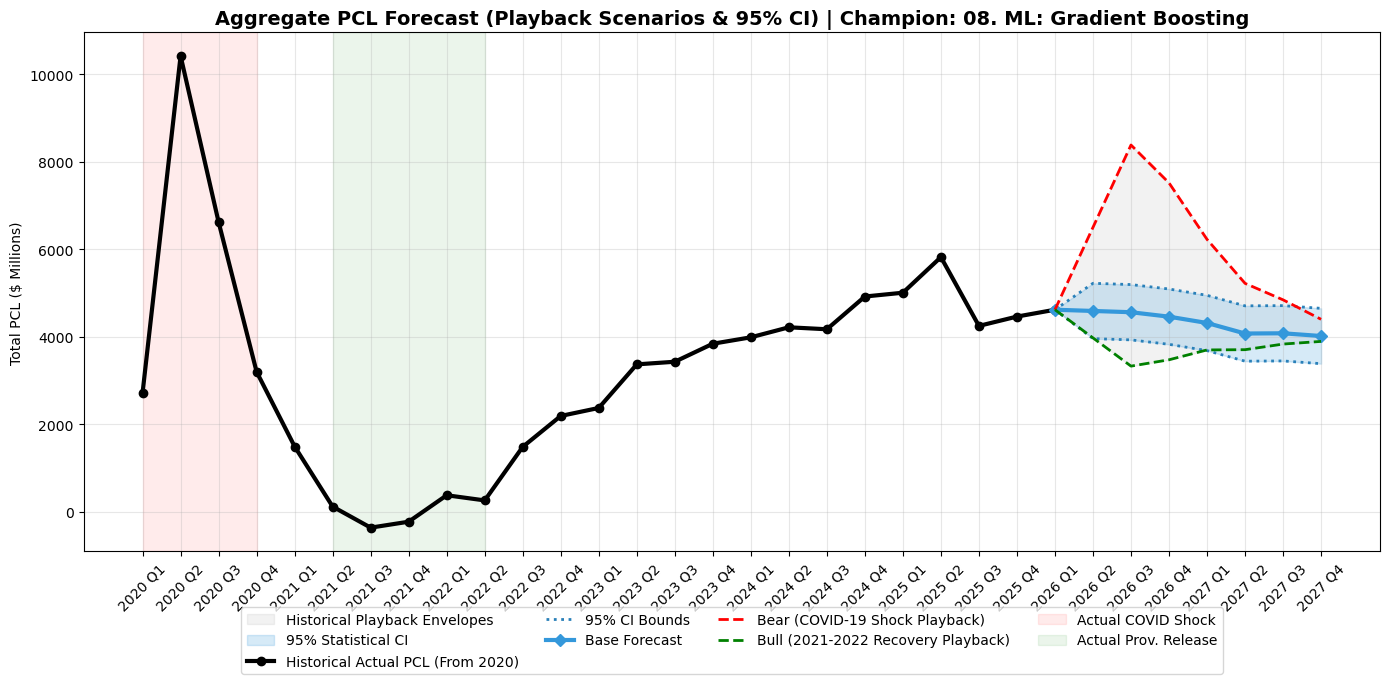

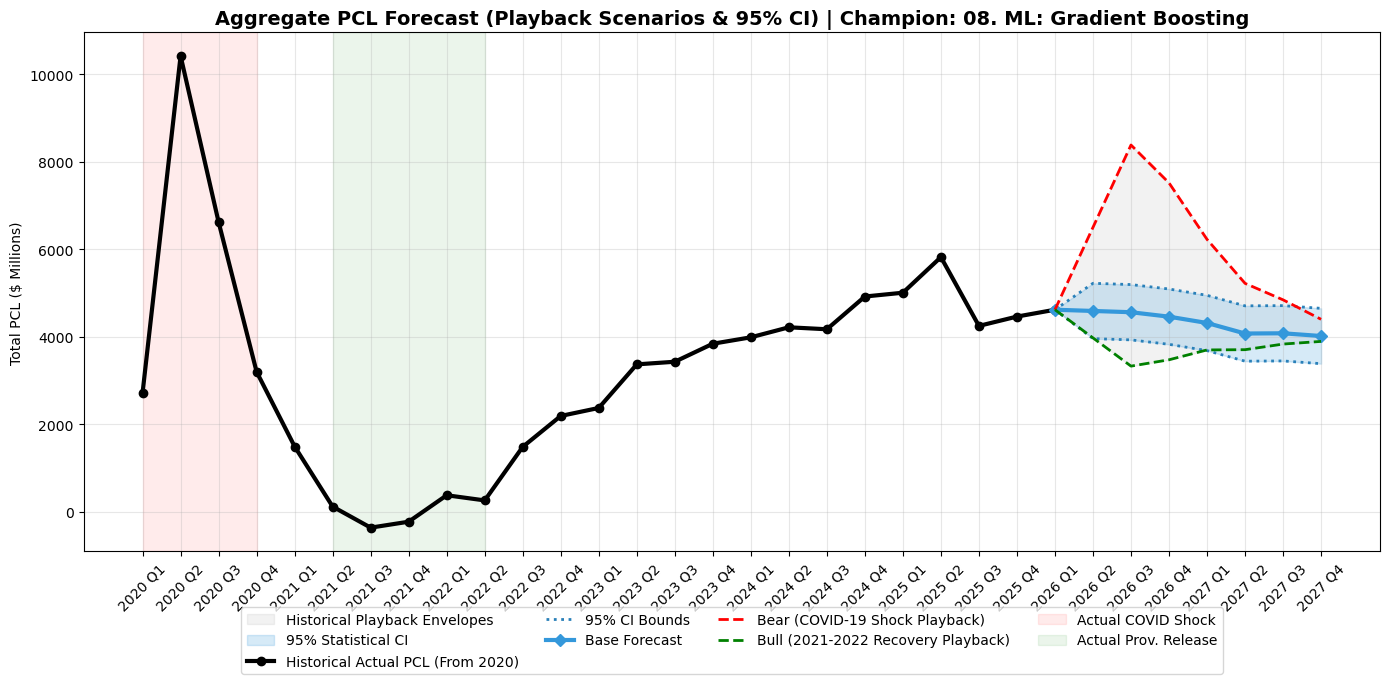

In [23]:
# ==============================================================================
# [CELL 4] PURE FORECAST, HISTORICAL PLAYBACK SCENARIOS & ENHANCED DASHBOARD
# ==============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit

print(f">>> [Cell 4] Deploying {best_ml_model_name} with COVID Historical Playback Logic...")

# 🌟 PIPELINE LINKAGE: Train champion strictly on selected_features_ml
sc_final = StandardScaler()
X_final_sc = sc_final.fit_transform(train_valid_df[selected_features_ml])
y_resid_final = train_valid_df["PCL_Residual_t+1"]

if "Lasso" in best_ml_model_name: champion_model = LassoCV(alphas=np.logspace(-2, 4, 50), cv=TimeSeriesSplit(n_splits=3))
elif "Ridge" in best_ml_model_name: champion_model = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=TimeSeriesSplit(n_splits=3))
elif "Random Forest" in best_ml_model_name: champion_model = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
else: champion_model = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)

champion_model.fit(X_final_sc, y_resid_final)

file_sheet1 = "Complete_UC2_Forecast_Data.xlsx"
raw_fcst_df = pd.read_excel(file_sheet1, sheet_name="Sheet1")
raw_fcst_df["Year"] = raw_fcst_df["Year"].fillna(0).astype(int)

agg_fcst_funcs = {"Bloomberg": "sum", "GDP YoY Forecast": "mean", "Unemployment Rate YoY QUARTER": "mean", "Overnight Rate": "mean"}
agg_fcst = raw_fcst_df.groupby(["Year", "Quarter"], as_index=False).agg(agg_fcst_funcs).sort_values(["Year", "Quarter"]).reset_index(drop=True)

f_idx = pd.DatetimeIndex(agg_fcst["Year"].astype(str) + "-" + agg_fcst["Quarter"].map({"Q1": "03-31", "Q2": "06-30", "Q3": "09-30", "Q4": "12-31"}))
fc_hor = len(f_idx)

# ARIMA Sentiment Extrapolation
agg_hist_nlp = model_df["Sent_BART_t"].dropna().values 
try:
    if HAS_PMDARIMA: future_nlp_base = auto_arima(agg_hist_nlp, seasonal=False, suppress_warnings=True).predict(n_periods=fc_hor)
    else: future_nlp_base = ARIMA(agg_hist_nlp, order=(1,0,0)).fit().forecast(steps=fc_hor)
except: future_nlp_base = np.repeat(agg_hist_nlp[-1], fc_hor)

future_pool_base = pd.DataFrame(index=range(fc_hor))
future_pool_base["CloseIn_GDP"] = agg_fcst["GDP YoY Forecast"].values
future_pool_base["Unemp_1_month_prior _to_t+1"] = agg_fcst["Unemployment Rate YoY QUARTER"].values
future_pool_base["Rfsh_Fcst_BoC_1_month_prior_to_t+1"] = agg_fcst["Overnight Rate"].values
future_pool_base["Sent_BART_t"] = future_nlp_base
future_pool_base["BART_x_CloseIn_Unemp"] = future_nlp_base * agg_fcst["Unemployment Rate YoY QUARTER"].values
future_pool_base["BART_x_CloseIn_BoC"] = future_nlp_base * agg_fcst["Overnight Rate"].values
future_pool_base["BART_x_CloseIn_GDP"] = future_nlp_base * agg_fcst["GDP YoY Forecast"].values

# Forecast Residuals -> Add back to BBG Base
bbg_future_base = agg_fcst["Bloomberg"].values
pcl_resid_pred = champion_model.predict(sc_final.transform(future_pool_base[selected_features_ml]))
pcl_base = bbg_future_base + pcl_resid_pred

# ==============================================================================
# 🌟 THE PROFESSOR'S LOGIC: "HISTORICAL PLAYBACK" FOR BEAR & BULL
# ==============================================================================
# 1. Bear Playback (COVID 2020 Shock Magnitude)
pre_covid = model_df.loc["2019-12-31", "PCL_t"] if "2019-12-31" in model_df.index else 1500
covid_peak = model_df.loc["2020-09-30", "PCL_t"] if "2020-09-30" in model_df.index else 6000
covid_shock_magnitude = max(0, covid_peak - pre_covid)

# 2. Bull Playback (2021-2022 Provision Release Magnitude)
pre_recovery = model_df.loc["2021-03-31", "PCL_t"] if "2021-03-31" in model_df.index else 1500
recovery_trough = model_df.loc["2022-06-30", "PCL_t"] if "2022-06-30" in model_df.index else 0
recovery_magnitude = max(0, pre_recovery - recovery_trough)

# 3. Create the impact curve (Spikes rapidly, then slowly normalizes)
playback_curve = np.array([0.5, 1.0, 0.8, 0.5, 0.3, 0.2, 0.1, 0.0])[:fc_hor]

# Apply Playbacks to the Base forecast
pcl_bear = pcl_base + (covid_shock_magnitude * playback_curve)
pcl_bull = pcl_base - (recovery_magnitude * playback_curve)

# Calculate the 95% Confidence Interval based on OOS RMSE
pcl_upper = pcl_base + 1.96 * best_rmse
pcl_lower = pcl_base - 1.96 * best_rmse

# ==============================================================================
# 🎯 FAN CHART: SEAMLESS INTEGER PLOTTING (Starts from 2020)
# ==============================================================================
# Pull history back to 2020 to show the events we are "playing back"
hist_dates = model_df[model_df.index >= "2020-01-01"].index
all_dates = list(hist_dates) + list(f_idx)

x_ticks = np.arange(len(all_dates))
x_labels = [f"{d.year} Q{d.quarter}" for d in all_dates]

y_hist = list(model_df.loc[hist_dates, "PCL_t"].values) + [np.nan] * fc_hor

springboard_val = model_df.loc[hist_dates[-1], "PCL_t"]
pad_length = len(hist_dates) - 1

y_base = [np.nan] * pad_length + [springboard_val] + list(pcl_base)
y_bear = [np.nan] * pad_length + [springboard_val] + list(pcl_bear)
y_bull = [np.nan] * pad_length + [springboard_val] + list(pcl_bull)
y_upper = [np.nan] * pad_length + [springboard_val] + list(pcl_upper)
y_lower = [np.nan] * pad_length + [springboard_val] + list(pcl_lower)

plt.close('all'); fig_fan, ax_fan = plt.subplots(figsize=(14, 7))

# Shaded areas
ax_fan.fill_between(x_ticks, np.fmin(y_bear, y_bull), np.fmax(y_bear, y_bull), alpha=0.10, color='gray', label="Historical Playback Envelopes")
ax_fan.fill_between(x_ticks, y_lower, y_upper, alpha=0.20, color='#3498db', label="95% Statistical CI")

# Plot Lines
ax_fan.plot(x_ticks, y_hist, 'k-o', label="Historical Actual PCL (From 2020)", linewidth=3.0)

# Explicitly plot 95% CI boundaries
ax_fan.plot(x_ticks, y_upper, color='#2980b9', linestyle=':', linewidth=2.0, label="95% CI Bounds")
ax_fan.plot(x_ticks, y_lower, color='#2980b9', linestyle=':', linewidth=2.0)

ax_fan.plot(x_ticks, y_base, color='#3498db', marker='D', label="Base Forecast", linewidth=3.0)
ax_fan.plot(x_ticks, y_bear, 'r--', label="Bear (COVID-19 Shock Playback)", linewidth=2.0)
ax_fan.plot(x_ticks, y_bull, 'g--', label="Bull (2021-2022 Recovery Playback)", linewidth=2.0)

# Shade the Historical Events for Context
try:
    c_start, c_end = list(hist_dates).index(pd.to_datetime("2020-03-31")), list(hist_dates).index(pd.to_datetime("2020-12-31"))
    ax_fan.axvspan(c_start, c_end, color='red', alpha=0.08, label="Actual COVID Shock")
    r_start, r_end = list(hist_dates).index(pd.to_datetime("2021-06-30")), list(hist_dates).index(pd.to_datetime("2022-06-30"))
    ax_fan.axvspan(r_start, r_end, color='green', alpha=0.08, label="Actual Prov. Release")
except: pass

ax_fan.set_xticks(x_ticks)
ax_fan.set_xticklabels(x_labels, rotation=45)
ax_fan.set_title(f"Aggregate PCL Forecast (Playback Scenarios & 95% CI) | Champion: {best_ml_model_name}", fontweight="bold", fontsize=14)
ax_fan.set_ylabel("Total PCL ($ Millions)")
ax_fan.grid(True, alpha=0.3); ax_fan.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.25))
plt.tight_layout(); display(fig_fan)

# ==============================================================================
# 🎯 INTERACTIVE DASHBOARD (5-TIER DISPLAY)
# ==============================================================================
ui_out = widgets.Output()
q_str_list = [f"{d.year} Q{d.quarter}" for d in f_idx]
drop = widgets.Dropdown(options=q_str_list, description='Future Quarter:')

def update_ui(change):
    selected_str = change.new if hasattr(change, 'new') else change
    idx_pos = q_str_list.index(selected_str)
    
    with ui_out:
        clear_output(wait=True)
        feature_rows_html = ""
        for feat in selected_features_ml:
            val = future_pool_base.loc[idx_pos, feat]
            feature_rows_html += f"<tr style='border-bottom:1px solid #eee;'><td><b>{feat}</b></td><td>{val:.4f}</td></tr>"

        html_str = f"""
        <div style="font-family:sans-serif; border:2px solid #2C3E50; border-radius:12px; padding:15px; max-width:950px;">
            <h2 style="color:#2C3E50; text-align:center; border-bottom:2px solid #BDC3C7;">🏦 Industry Aggregate PCL Dashboard<br><span style="font-size:16px;">Quarter: {selected_str}</span></h2>
            <div style="display:flex; justify-content:space-between;">
                <div style="width:48%;">
                    <h3 style="color:#2C3E50;">🎯 Final Projections ($M)</h3>
                    
                    <p style="color:#c0392b; margin:4px 0;">🔴 <b>Bear (COVID Playback):</b> <span style="float:right; font-weight:bold;">${pcl_bear[idx_pos]:,.0f}</span></p>
                    <p style="color:#2980b9; margin:4px 0; font-size: 0.9em;">🔺 <b>95% CI Upper Bound:</b> <span style="float:right;">${pcl_upper[idx_pos]:,.0f}</span></p>
                    
                    <div style="background:#D6EAF8; padding:10px; border-radius:5px; margin: 10px 0; border-left: 4px solid #3498db;">
                        🔵 <b>BBG Consensus:</b> <span style="float:right; color:#555;">${bbg_future_base[idx_pos]:,.0f}</span><br>
                        🔵 <b>ML Residual Delta:</b> <span style="float:right; color:#555;">{pcl_resid_pred[idx_pos]:+,.0f}</span><br>
                        <div style="border-bottom: 1px solid #BDC3C7; margin: 4px 0;"></div>
                        <b>Total ML Base:</b> <span style="float:right; font-weight:bold; font-size:1.1em;">${pcl_base[idx_pos]:,.0f}</span>
                        <div style="clear:both;"></div>
                    </div>
                    
                    <p style="color:#2980b9; margin:4px 0; font-size: 0.9em;">🔻 <b>95% CI Lower Bound:</b> <span style="float:right;">${pcl_lower[idx_pos]:,.0f}</span></p>
                    <p style="color:#27ae60; margin:4px 0;">🟢 <b>Bull (Recovery Playback):</b> <span style="float:right; font-weight:bold;">${pcl_bull[idx_pos]:,.0f}</span></p>
                </div>
                
                <div style="width:48%; border-left:2px dashed #BDC3C7; padding-left:15px;">
                    <h3 style="color:#2980b9;">📊 Features Driving the Delta</h3>
                    <table style="width:100%; font-size:12px; border-collapse:collapse;">
                        <tr style="color:#7F8C8D; border-bottom:1px solid #ccc;"><th align="left">Feature</th><th>Assumed Value</th></tr>
                        {feature_rows_html}
                    </table>
                </div>
            </div>
        </div>
        """
        display(HTML(html_str))

drop.observe(update_ui, names='value')
display(widgets.VBox([drop, ui_out]))
update_ui(drop.value)

# ELASTIC NET SELECTION

In [24]:
# ==============================================================================
# [CELL 1] AGGREGATE PCL - ROBUST PARSING & RESIDUAL MODELING SETUP
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm
import os

try:
    from pmdarima import auto_arima
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False

PD_VER = int(pd.__version__.split(".")[0])
Q_FREQ = "QE" if PD_VER >= 2 else "Q"

print(">>> [Cell 1] Initializing Core Data Engine & Residual (Delta) Target...")

# 1. Bulletproof parser for accounting formats (e.g., "(150)" -> -150.0)
def clean_num(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float)): return float(x)
    s = str(x).strip().replace(",", "").replace("$", "").replace(" ", "")
    if s in ["—", "", "-", "NA", "N/A", "nan", "NaN"]: return np.nan
    if s.startswith("(") and s.endswith(")"): s = "-" + s[1:-1]
    try: return float(s)
    except Exception: return np.nan

file_hist = "Complete_UC2_Forecast_Data.xlsx"
raw_df = pd.read_excel(file_hist, sheet_name="Forecast Data", header=1)

cols_to_clean = ["PCL_t+1", "PCL_t", "BBG_Fcst_for_PCL_t+1", 
                 "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1", "Unemp_1_month_prior _to_t+1", 
                 "Rfsh_Fcst_BoC_1_month_prior_to_t+1", "Sent_BART_t", "GDP_YoY_t", "Overnight_Rate_t"]
for c in cols_to_clean:
    if c in raw_df.columns: raw_df[c] = raw_df[c].apply(clean_num)

# 2. Forward/Backward fill missing macro values intra-bank
raw_df = raw_df.sort_values(by=["Bank", "Year", "Quarter"])
cols_to_fill = ["PCL_t", "BBG_Fcst_for_PCL_t+1", "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1", "Unemp_1_month_prior _to_t+1", "Rfsh_Fcst_BoC_1_month_prior_to_t+1", "Sent_BART_t"]
for c in cols_to_fill:
    if c in raw_df.columns: 
        raw_df[c] = raw_df.groupby("Bank")[c].transform(lambda x: x.ffill().bfill())

def sum_safe(x): return x.sum(min_count=1)

agg_funcs = {
    "PCL_t+1": sum_safe, "PCL_t": sum_safe, "BBG_Fcst_for_PCL_t+1": sum_safe,
    "Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1": "mean", "Unemp_1_month_prior _to_t+1": "mean",
    "Rfsh_Fcst_BoC_1_month_prior_to_t+1": "mean", "Sent_BART_t": "mean", 
    "GDP_YoY_t": "mean", "Overnight_Rate_t": "mean"
}
agg_funcs = {k: v for k, v in agg_funcs.items() if k in raw_df.columns}

agg_df = raw_df.groupby(["Year", "Quarter"], as_index=False).agg(agg_funcs)
q_map = {"Q1": "03-31", "Q2": "06-30", "Q3": "09-30", "Q4": "12-31"}
agg_df.index = pd.DatetimeIndex(agg_df["Year"].fillna(0).astype(int).astype(str) + "-" + agg_df["Quarter"].map(q_map))
agg_df = agg_df.sort_index().asfreq(Q_FREQ)

agg_df = agg_df[agg_df.index <= "2026-03-31"]

# 🌟 TARGET: AI predicts the Residual Delta against Bloomberg Consensus
agg_df["PCL_Residual_t+1"] = agg_df["PCL_t+1"] - agg_df["BBG_Fcst_for_PCL_t+1"]

# Build Multiplier/Interaction Features
agg_df["CloseIn_GDP"] = agg_df["Rfsh_Fcst_GDP_YoY_1_month_prior_to_t+1"]
agg_df["BART_x_CloseIn_Unemp"] = agg_df["Sent_BART_t"] * agg_df["Unemp_1_month_prior _to_t+1"]
agg_df["BART_x_CloseIn_BoC"] = agg_df["Sent_BART_t"] * agg_df["Rfsh_Fcst_BoC_1_month_prior_to_t+1"]
agg_df["BART_x_CloseIn_GDP"] = agg_df["Sent_BART_t"] * agg_df["CloseIn_GDP"]

candidate_features = [
    "CloseIn_GDP", "Unemp_1_month_prior _to_t+1", "Rfsh_Fcst_BoC_1_month_prior_to_t+1",
    "Sent_BART_t", "BART_x_CloseIn_Unemp", "BART_x_CloseIn_BoC", "BART_x_CloseIn_GDP"
]
features_ts_hist = ["GDP_YoY_t", "Overnight_Rate_t"] 

model_df = agg_df[["PCL_t+1", "PCL_t", "BBG_Fcst_for_PCL_t+1", "PCL_Residual_t+1", "Year", "Quarter"] + candidate_features + features_ts_hist].copy()

print(f"✅ Cell 1 Complete! Data restored. 2026 Q1 Actual PCL_t base: ${model_df['PCL_t'].dropna().iloc[-1]:,.0f}M")

>>> [Cell 1] Initializing Core Data Engine & Residual (Delta) Target...
✅ Cell 1 Complete! Data restored. 2026 Q1 Actual PCL_t base: $4,619M



>>> [Cell 2&3] Executing Residual ML Pipeline (Elastic Net Enabled)...

🔍 PROCESS 1: ELASTIC NET SELECTION RESULTS (Optimum L1 Ratio: 0.7)
  ✅ KEPT     : CloseIn_GDP                         (Residual Weight:  -351.46)
  ✅ KEPT     : Unemp_1_month_prior _to_t+1         (Residual Weight:  -113.24)
  ✅ KEPT     : Rfsh_Fcst_BoC_1_month_prior_to_t+1  (Residual Weight:   120.42)
  ✅ KEPT     : Sent_BART_t                         (Residual Weight:   209.70)
  ✅ KEPT     : BART_x_CloseIn_Unemp                (Residual Weight:   -75.71)
  ✅ KEPT     : BART_x_CloseIn_BoC                  (Residual Weight:   128.50)
  ✅ KEPT     : BART_x_CloseIn_GDP                  (Residual Weight:  -350.02)

📘 TABLE 1: PERFORMANCE IMPROVEMENT (Strict Rolling OOS)


Metric,05. ML: Elastic Net,BBG Raw Baseline,Improvement
OOS R²,0.6111,0.6102,+0.0009
OOS MAPE (%),6.2018,5.1390,+1.0628
OOS RMSE ($M),325.4658,325.8493,-0.3834



🎯 UNIFIED 8-MODEL SCORECARD (Predicting Bloomberg Delta)


Model,OOS R2,OOS MAPE,OOS RMSE
02. Baseline: Bloomberg Consensus,0.6102,5.14%,325.8
05. ML: Elastic Net,0.6111,6.20%,325.5
08. ML: Gradient Boosting,0.4658,6.76%,381.5
06. ML: Ridge,0.5472,7.17%,351.2
07. ML: Random Forest,0.3476,7.56%,421.5
03. TimeSeries: SARIMA,0.1660,7.72%,476.6
04. TimeSeries: VAR,0.1214,8.25%,489.2
01. Baseline: Naive (Last Qtr),-1.1770,14.52%,770.1


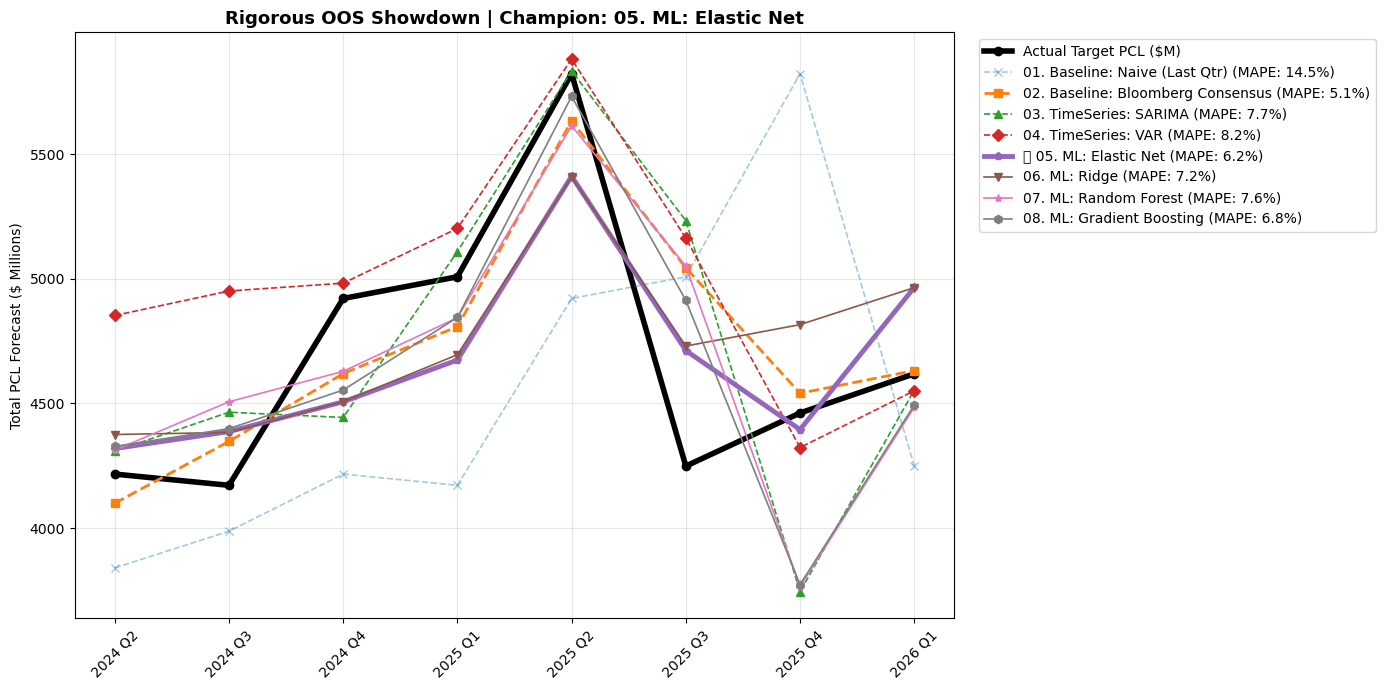

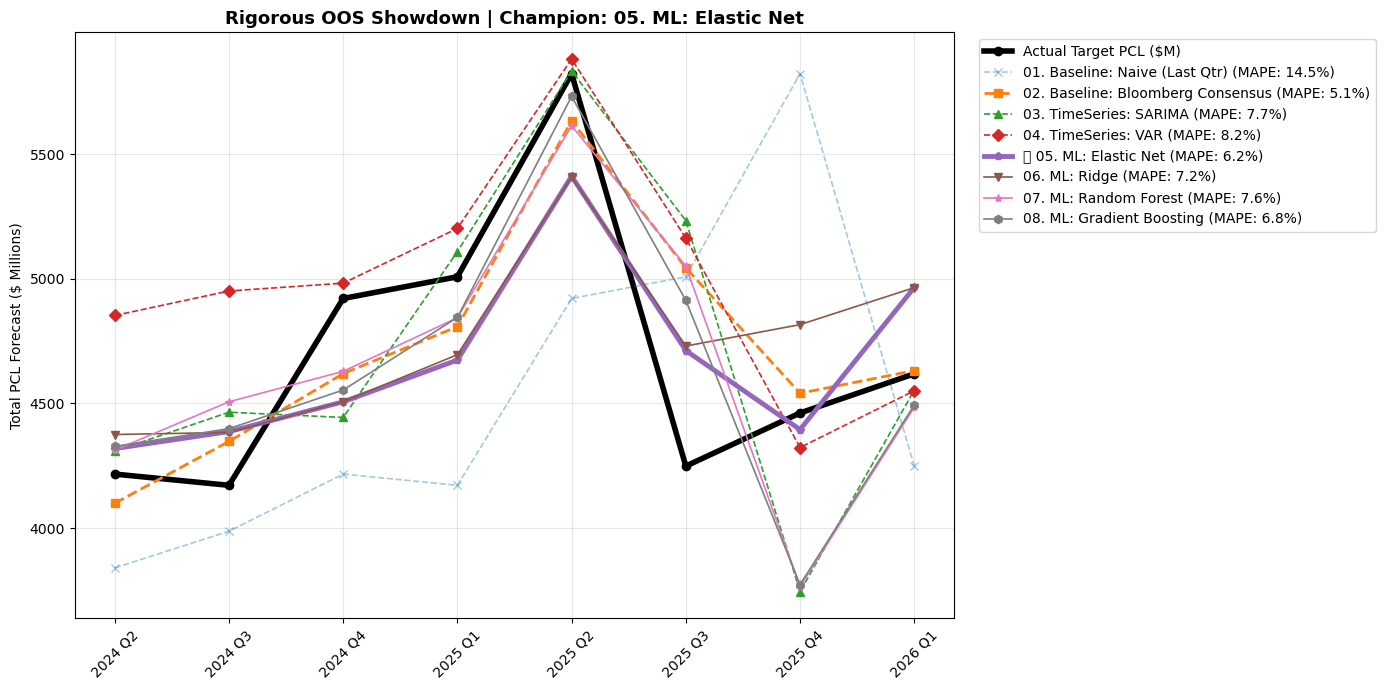

In [25]:
# ==============================================================================
# [CELL 2&3] ELASTIC NET DYNAMIC SELECTION & ROLLING OOS BACKTEST
# ==============================================================================
print(f"\n>>> [Cell 2&3] Executing Residual ML Pipeline (Elastic Net Enabled)...\n")

# Isolate valid rows where the target residual actually happened
train_valid_df = model_df.dropna(subset=["PCL_Residual_t+1"]).copy()

# ==============================================================================
# 🎯 PROCESS 1: ELASTIC NET FEATURE SELECTION (Predicting the Delta)
# ==============================================================================
tscv_fs = TimeSeriesSplit(n_splits=3)
X_cand_sc = StandardScaler().fit_transform(train_valid_df[candidate_features])
y_resid = train_valid_df["PCL_Residual_t+1"].values

# Elastic Net avoids dropping correlated macro variables blindly
elastic_fs = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0], cv=tscv_fs, random_state=42).fit(X_cand_sc, y_resid)

selected_features_ml = []
print("="*85)
print(f"🔍 PROCESS 1: ELASTIC NET SELECTION RESULTS (Optimum L1 Ratio: {elastic_fs.l1_ratio_})")
print("="*85)
for feat, coef in zip(candidate_features, elastic_fs.coef_):
    status = "✅ KEPT" if abs(coef) > 1e-4 else "❌ PRUNED"
    if abs(coef) > 1e-4: selected_features_ml.append(feat)
    print(f"  {status:10s} : {feat:35s} (Residual Weight: {coef:>8.2f})")

if not selected_features_ml: 
    print("⚠️ Fallback activated: Forced to keep baseline features.")
    selected_features_ml = ["CloseIn_GDP", "Sent_BART_t"]

# ==============================================================================
# 🎯 PROCESS 2: 8-MODEL RIGOROUS ROLLING OOS BACKTEST
# ==============================================================================
tscv = TimeSeriesSplit(n_splits=3)
ml_models_dict = {
    "05. ML: Elastic Net": ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=tscv),
    "06. ML: Ridge": RidgeCV(alphas=np.logspace(-2, 4, 50), cv=tscv),
    "07. ML: Random Forest": RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42),
    "08. ML: Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)
}

h_test = 8  
test_indices = list(range(len(train_valid_df) - h_test, len(train_valid_df)))
prediction_records = []

for t in test_indices:
    if t < 12: continue
    train_df, test_row = train_valid_df.iloc[:t], train_valid_df.iloc[t:t+1]
    
    y_tr_resid = train_df["PCL_Residual_t+1"]
    y_actual = float(test_row["PCL_t+1"].iloc[0]) # The absolute actual
    bbg_base_pred = float(test_row["BBG_Fcst_for_PCL_t+1"].iloc[0]) # The consensus base
    
    target_dt = test_row.index[0] + pd.offsets.QuarterEnd(1)
    yr, qtr = int(target_dt.year), f"Q{target_dt.quarter}"
    
    def eval_mod(m_name, p_val): prediction_records.append({'Year': yr, 'Quarter': qtr, 'Model': m_name, 'Predicted ($M)': float(np.squeeze(p_val)), 'Actual ($M)': y_actual})
    
    eval_mod("01. Baseline: Naive (Last Qtr)", train_df["PCL_t"].iloc[-1])
    eval_mod("02. Baseline: Bloomberg Consensus", bbg_base_pred)
    
    try:
        if HAS_PMDARIMA: sar_p = auto_arima(y_tr_resid, X=train_df[features_ts_hist], seasonal=False, suppress_warnings=True).predict(n_periods=1, X=test_row[features_ts_hist])[0]
        else: sar_p = ARIMA(y_tr_resid.values, exog=train_df[features_ts_hist].values, order=(1,0,0)).fit().forecast(steps=1, exog=test_row[features_ts_hist].values)[0]
        eval_mod("03. TimeSeries: SARIMA", bbg_base_pred + sar_p)
    except: eval_mod("03. TimeSeries: SARIMA", bbg_base_pred + y_tr_resid.iloc[-1])

    try: 
        var_p = VAR(train_df[["PCL_Residual_t+1"] + features_ts_hist]).fit(maxlags=1).forecast(train_df[["PCL_Residual_t+1"] + features_ts_hist].values[-1:], steps=1)[0, 0]
        eval_mod("04. TimeSeries: VAR", bbg_base_pred + var_p)
    except: eval_mod("04. TimeSeries: VAR", bbg_base_pred + y_tr_resid.iloc[-1])

    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(train_df[selected_features_ml])
    X_te_sc = sc.transform(test_row[selected_features_ml])
    
    for m_name, model in ml_models_dict.items():
        ml_resid = model.fit(X_tr_sc, y_tr_resid).predict(X_te_sc)[0]
        eval_mod(m_name, bbg_base_pred + ml_resid) # ML Output = BBG Base + ML Delta

results_df = pd.DataFrame(prediction_records)
metrics_list = []
for model_name, grp in results_df.groupby("Model"):
    valid = grp.dropna(subset=["Predicted ($M)", "Actual ($M)"])
    if len(valid) > 0:
        y_a, y_p = valid["Actual ($M)"].values.astype(float), valid["Predicted ($M)"].values.astype(float)
        # Safe MAPE using absolute values
        metrics_list.append({"Model": model_name, "OOS R2": r2_score(y_a, y_p), "OOS MAPE": float(np.mean(np.abs((y_a - y_p) / np.abs(y_a)))) * 100, "OOS RMSE": float(np.sqrt(np.mean((y_a - y_p)**2)))})

final_table = pd.DataFrame(metrics_list).sort_values(by="OOS MAPE").reset_index(drop=True)
best_ml_model_name = final_table[final_table["Model"].str.contains("ML:")]["Model"].iloc[0]
best_rmse = final_table[final_table["Model"].str.contains("ML:")]["OOS RMSE"].iloc[0]

# ==============================================================================
# 🎯 PROCESS 3: ACADEMIC TABLES & SHOWDOWN SCORECARD
# ==============================================================================
bbg_stats = final_table[final_table["Model"] == "02. Baseline: Bloomberg Consensus"].iloc[0]
champ_stats = final_table[final_table["Model"] == best_ml_model_name].iloc[0]

table_1 = pd.DataFrame({
    "Metric": ["OOS R²", "OOS MAPE (%)", "OOS RMSE ($M)"],
    f"{best_ml_model_name}": [champ_stats["OOS R2"], champ_stats["OOS MAPE"], champ_stats["OOS RMSE"]],
    "BBG Raw Baseline": [bbg_stats["OOS R2"], bbg_stats["OOS MAPE"], bbg_stats["OOS RMSE"]]
})
table_1["Improvement"] = table_1[f"{best_ml_model_name}"] - table_1["BBG Raw Baseline"]

print("\n" + "="*85)
print(f"📘 TABLE 1: PERFORMANCE IMPROVEMENT (Strict Rolling OOS)")
print("="*85)
display(table_1.style.format({f"{best_ml_model_name}": "{:.4f}", "BBG Raw Baseline": "{:.4f}", "Improvement": "{:+.4f}"}).set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis="index"))

print("\n" + "="*85)
print("🎯 UNIFIED 8-MODEL SCORECARD (Predicting Bloomberg Delta)")
print("="*85)
display(final_table.style.format({"OOS R2": "{:.4f}", "OOS MAPE": "{:.2f}%", "OOS RMSE": "{:.1f}"}).set_properties(**{'text-align': 'center', 'border': '1px solid black'}).hide(axis="index").background_gradient(subset=['OOS MAPE'], cmap='Blues'))

plt.close('all'); fig_sd, ax_sd = plt.subplots(figsize=(14, 7))
detail_df = results_df[results_df["Model"] == best_ml_model_name]
time_labels = [f"{y} {q}" for y, q in zip(detail_df["Year"], detail_df["Quarter"])]
x_ticks_sd = np.arange(len(time_labels))

ax_sd.plot(x_ticks_sd, detail_df["Actual ($M)"].values, 'k-o', label="Actual Target PCL ($M)", linewidth=4.0)
colors, markers = sns.color_palette("tab10", len(metrics_list)), ['x', 's', '^', 'D', 'p', 'v', '*', 'h']
for i, m_name in enumerate(sorted(final_table["Model"])):
    m_data = results_df[results_df["Model"] == m_name]
    lw = 3.5 if m_name == best_ml_model_name else (2.0 if 'Bloomberg' in m_name else 1.2)
    ax_sd.plot(x_ticks_sd, m_data["Predicted ($M)"].values, linestyle='--' if 'Baseline' in m_name or 'TimeSeries' in m_name else '-', marker=markers[i%len(markers)], color=colors[i], label=f"{'🏆 ' if m_name == best_ml_model_name else ''}{m_name} (MAPE: {final_table[final_table['Model'] == m_name]['OOS MAPE'].iloc[0]:.1f}%)", linewidth=lw, alpha=0.4 if 'Naive' in m_name else 1.0)

ax_sd.set_xticks(x_ticks_sd); ax_sd.set_xticklabels(time_labels, rotation=45)
ax_sd.set_title(f"Rigorous OOS Showdown | Champion: {best_ml_model_name}", fontweight="bold", fontsize=13); ax_sd.set_ylabel("Total PCL Forecast ($ Millions)"); ax_sd.grid(True, alpha=0.3); ax_sd.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)
plt.tight_layout(); display(fig_sd)

>>> [Cell 4] Deploying 05. ML: Elastic Net to Forecast the Future Delta...


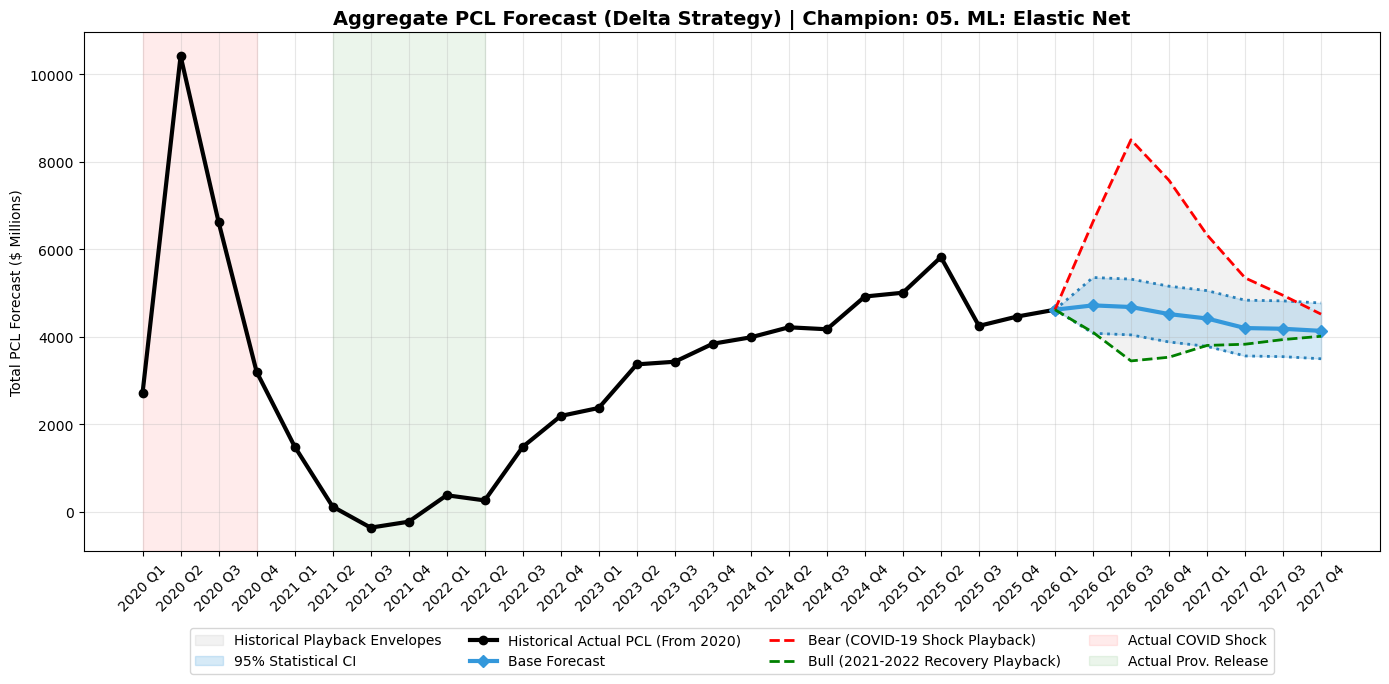

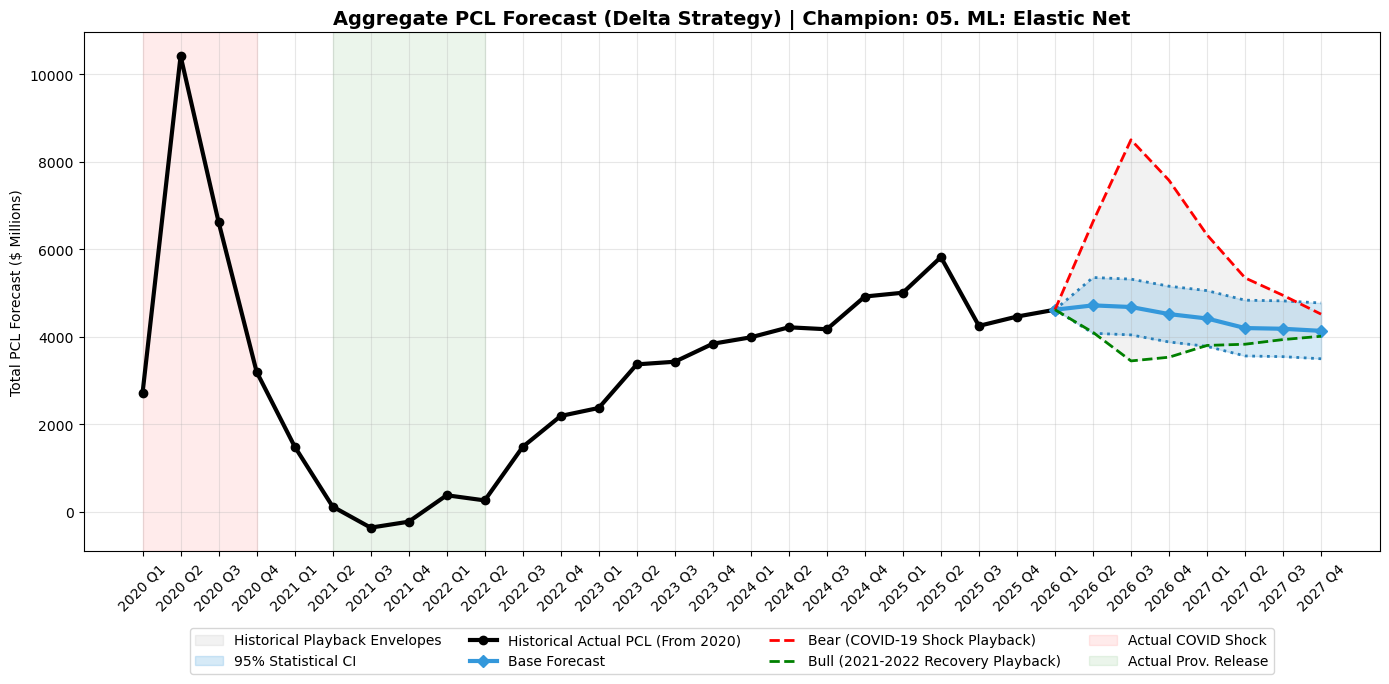

In [26]:
# ==============================================================================
# [CELL 4] PURE FORECAST, HISTORICAL PLAYBACK & 5-TIER DASHBOARD
# ==============================================================================
import os

print(f">>> [Cell 4] Deploying {best_ml_model_name} to Forecast the Future Delta...")

sc_final = StandardScaler()
X_final_sc = sc_final.fit_transform(train_valid_df[selected_features_ml])
y_resid_final = train_valid_df["PCL_Residual_t+1"]

if "Elastic Net" in best_ml_model_name or "Lasso" in best_ml_model_name: champion_model = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=TimeSeriesSplit(n_splits=3))
elif "Ridge" in best_ml_model_name: champion_model = RidgeCV(alphas=np.logspace(-2, 4, 50), cv=TimeSeriesSplit(n_splits=3))
elif "Random Forest" in best_ml_model_name: champion_model = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
else: champion_model = GradientBoostingRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)

champion_model.fit(X_final_sc, y_resid_final)

file_sheet1 = "Complete_UC2_Forecast_Data.xlsx"
raw_fcst_df = pd.read_excel(file_sheet1, sheet_name="Sheet1")
raw_fcst_df["Year"] = raw_fcst_df["Year"].fillna(0).astype(int)

agg_fcst_funcs = {"Bloomberg": "sum", "GDP YoY Forecast": "mean", "Unemployment Rate YoY QUARTER": "mean", "Overnight Rate": "mean"}
agg_fcst = raw_fcst_df.groupby(["Year", "Quarter"], as_index=False).agg(agg_fcst_funcs).sort_values(["Year", "Quarter"]).reset_index(drop=True)

f_idx = pd.DatetimeIndex(agg_fcst["Year"].astype(str) + "-" + agg_fcst["Quarter"].map({"Q1": "03-31", "Q2": "06-30", "Q3": "09-30", "Q4": "12-31"}))
fc_hor = len(f_idx)

agg_hist_nlp = model_df["Sent_BART_t"].dropna().values 
try:
    if HAS_PMDARIMA: future_nlp_base = auto_arima(agg_hist_nlp, seasonal=False, suppress_warnings=True).predict(n_periods=fc_hor)
    else: future_nlp_base = ARIMA(agg_hist_nlp, order=(1,0,0)).fit().forecast(steps=fc_hor)
except: future_nlp_base = np.repeat(agg_hist_nlp[-1], fc_hor)

future_pool_base = pd.DataFrame(index=range(fc_hor))
future_pool_base["CloseIn_GDP"] = agg_fcst["GDP YoY Forecast"].values
future_pool_base["Unemp_1_month_prior _to_t+1"] = agg_fcst["Unemployment Rate YoY QUARTER"].values
future_pool_base["Rfsh_Fcst_BoC_1_month_prior_to_t+1"] = agg_fcst["Overnight Rate"].values
future_pool_base["Sent_BART_t"] = future_nlp_base
future_pool_base["BART_x_CloseIn_Unemp"] = future_nlp_base * agg_fcst["Unemployment Rate YoY QUARTER"].values
future_pool_base["BART_x_CloseIn_BoC"] = future_nlp_base * agg_fcst["Overnight Rate"].values
future_pool_base["BART_x_CloseIn_GDP"] = future_nlp_base * agg_fcst["GDP YoY Forecast"].values

# 🌟 Core Prediction Logic: ML Delta + BBG Base
bbg_future_base = agg_fcst["Bloomberg"].values
pcl_resid_pred = champion_model.predict(sc_final.transform(future_pool_base[selected_features_ml]))
pcl_base = bbg_future_base + pcl_resid_pred

# 🌟 Historical Playback Logic (Overlay)
pre_covid = model_df.loc["2019-12-31", "PCL_t"] if "2019-12-31" in model_df.index else 1500
covid_peak = model_df.loc["2020-09-30", "PCL_t"] if "2020-09-30" in model_df.index else 6000
covid_shock_magnitude = max(0, covid_peak - pre_covid)

pre_recovery = model_df.loc["2021-03-31", "PCL_t"] if "2021-03-31" in model_df.index else 1500
recovery_trough = model_df.loc["2022-06-30", "PCL_t"] if "2022-06-30" in model_df.index else 0
recovery_magnitude = max(0, pre_recovery - recovery_trough)

playback_curve = np.array([0.5, 1.0, 0.8, 0.5, 0.3, 0.2, 0.1, 0.0])[:fc_hor]
bear_shock_array = covid_shock_magnitude * playback_curve
bull_shock_array = - (recovery_magnitude * playback_curve)

pcl_bear = pcl_base + bear_shock_array
pcl_bull = pcl_base + bull_shock_array

ci_spread = 1.96 * best_rmse
pcl_upper = pcl_base + ci_spread
pcl_lower = pcl_base - ci_spread

# ==============================================================================
# 🎯 FAN CHART: SEAMLESS ALIGNMENT (From 2020)
# ==============================================================================
hist_dates = model_df[model_df.index >= "2020-01-01"].index
all_dates = list(hist_dates) + list(f_idx)

x_ticks = np.arange(len(all_dates))
x_labels = [f"{d.year} Q{d.quarter}" for d in all_dates]

y_hist = list(model_df.loc[hist_dates, "PCL_t"].values) + [np.nan] * fc_hor
pad_length = len(hist_dates) - 1
springboard_val = model_df.loc[hist_dates[-1], "PCL_t"]

y_base = [np.nan] * pad_length + [springboard_val] + list(pcl_base)
y_bear = [np.nan] * pad_length + [springboard_val] + list(pcl_bear)
y_bull = [np.nan] * pad_length + [springboard_val] + list(pcl_bull)
y_upper = [np.nan] * pad_length + [springboard_val] + list(pcl_upper)
y_lower = [np.nan] * pad_length + [springboard_val] + list(pcl_lower)

plt.close('all'); fig_fan, ax_fan = plt.subplots(figsize=(14, 7))

ax_fan.fill_between(x_ticks, np.fmin(y_bear, y_bull), np.fmax(y_bear, y_bull), alpha=0.10, color='gray', label="Historical Playback Envelopes")
ax_fan.fill_between(x_ticks, y_lower, y_upper, alpha=0.20, color='#3498db', label="95% Statistical CI")

ax_fan.plot(x_ticks, y_hist, 'k-o', label="Historical Actual PCL (From 2020)", linewidth=3.0)
ax_fan.plot(x_ticks, y_upper, color='#2980b9', linestyle=':', linewidth=2.0)
ax_fan.plot(x_ticks, y_lower, color='#2980b9', linestyle=':', linewidth=2.0)

ax_fan.plot(x_ticks, y_base, color='#3498db', marker='D', label="Base Forecast", linewidth=3.0)
ax_fan.plot(x_ticks, y_bear, 'r--', label="Bear (COVID-19 Shock Playback)", linewidth=2.0)
ax_fan.plot(x_ticks, y_bull, 'g--', label="Bull (2021-2022 Recovery Playback)", linewidth=2.0)

try:
    c_start, c_end = list(hist_dates).index(pd.to_datetime("2020-03-31")), list(hist_dates).index(pd.to_datetime("2020-12-31"))
    ax_fan.axvspan(c_start, c_end, color='red', alpha=0.08, label="Actual COVID Shock")
    r_start, r_end = list(hist_dates).index(pd.to_datetime("2021-06-30")), list(hist_dates).index(pd.to_datetime("2022-06-30"))
    ax_fan.axvspan(r_start, r_end, color='green', alpha=0.08, label="Actual Prov. Release")
except: pass

ax_fan.set_xticks(x_ticks); ax_fan.set_xticklabels(x_labels, rotation=45)
ax_fan.set_title(f"Aggregate PCL Forecast (Delta Strategy) | Champion: {best_ml_model_name}", fontweight="bold", fontsize=14)
ax_fan.set_ylabel("Total PCL Forecast ($ Millions)"); ax_fan.grid(True, alpha=0.3); ax_fan.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.25))
plt.tight_layout(); display(fig_fan)

# ==============================================================================
# 🎯 INTERACTIVE 5-COLUMN SCENARIO DASHBOARD
# ==============================================================================
ui_out = widgets.Output()
q_str_list = [f"{d.year} Q{d.quarter}" for d in f_idx]
drop = widgets.Dropdown(options=q_str_list, description='Future Quarter:')

def update_ui(change):
    selected_str = change.new if hasattr(change, 'new') else change
    idx_pos = q_str_list.index(selected_str)
    
    with ui_out:
        clear_output(wait=True)
        feature_rows_html = ""
        # The base macro features are identically applied to all scenarios as the consensus foundation
        for feat in selected_features_ml:
            val = future_pool_base.loc[idx_pos, feat]
            feature_rows_html += f"<tr><td><b>{feat}</b></td><td colspan='5' style='text-align:center; color:#7F8C8D;'>{val:.3f} (Consensus Base)</td></tr>"

        b_shock = bear_shock_array[idx_pos]
        u_shock = bull_shock_array[idx_pos]
        
        html_str = f"""
        <div style="font-family:sans-serif; border:2px solid #2C3E50; border-radius:12px; padding:15px; max-width:1050px;">
            <h2 style="color:#2C3E50; text-align:center; border-bottom:2px solid #BDC3C7;">🏦 Industry Scenarios & AI Delta Dashboard<br><span style="font-size:16px;">Quarter: {selected_str}</span></h2>
            
            <table style="width:100%; font-size:13px; border-collapse:collapse; margin-top:15px;">
                <tr style="background-color:#2C3E50; color:white; text-align:center;">
                    <th style="padding:10px; text-align:left;">Features & Overlays</th>
                    <th style="padding:10px;">95% CI Lower</th>
                    <th style="padding:10px;">Bull (Recovery)</th>
                    <th style="padding:10px; background-color:#34495E; font-size:1.1em;">Base ML Forecast</th>
                    <th style="padding:10px;">Bear (COVID Shock)</th>
                    <th style="padding:10px;">95% CI Upper</th>
                </tr>
                {feature_rows_html}
                <tr style="border-top:2px solid #BDC3C7;">
                    <td style="padding:8px;"><b>1. Bloomberg Consensus Base</b></td>
                    <td colspan="5" style="text-align:center; color:#555; background-color:#EAEDED;">${bbg_future_base[idx_pos]:,.0f}</td>
                </tr>
                <tr>
                    <td style="padding:8px;"><b>2. ML Predicted Delta</b></td>
                    <td colspan="5" style="text-align:center; color:#2980b9; background-color:#EAEDED; font-weight:bold;">{pcl_resid_pred[idx_pos]:+,.0f}</td>
                </tr>
                <tr style="border-top:2px solid #BDC3C7;">
                    <td style="padding:8px;"><b>3. Statistical Confidence Limits</b></td>
                    <td style="text-align:center; color:#2980b9;">-${ci_spread:,.0f}</td>
                    <td style="text-align:center; color:#ccc;">-</td>
                    <td style="text-align:center; background-color:#F2F4F4;">$0</td>
                    <td style="text-align:center; color:#ccc;">-</td>
                    <td style="text-align:center; color:#c0392b;">+${ci_spread:,.0f}</td>
                </tr>
                <tr>
                    <td style="padding:8px;"><b>4. Historical Playback Overlay</b></td>
                    <td style="text-align:center; color:#ccc;">-</td>
                    <td style="text-align:center; color:#27ae60;">${u_shock:+,.0f}</td>
                    <td style="text-align:center; background-color:#F2F4F4;">$0</td>
                    <td style="text-align:center; color:#c0392b;">+${b_shock:,.0f}</td>
                    <td style="text-align:center; color:#ccc;">-</td>
                </tr>
                <tr style="border-top:2px solid #2C3E50; font-size:15px;">
                    <td style="padding:12px;"><b>Final PCL Projection ($M)</b></td>
                    <td style="text-align:center; font-weight:bold; color:#2980b9;">${pcl_lower[idx_pos]:,.0f}</td>
                    <td style="text-align:center; font-weight:bold; color:#27ae60;">${pcl_bull[idx_pos]:,.0f}</td>
                    <td style="text-align:center; font-weight:bold; background-color:#D6EAF8; font-size:1.15em;">${pcl_base[idx_pos]:,.0f}</td>
                    <td style="text-align:center; font-weight:bold; color:#c0392b;">${pcl_bear[idx_pos]:,.0f}</td>
                    <td style="text-align:center; font-weight:bold; color:#c0392b;">${pcl_upper[idx_pos]:,.0f}</td>
                </tr>
            </table>
        </div>
        """
        display(HTML(html_str))

drop.observe(update_ui, names='value')
display(widgets.VBox([drop, ui_out]))
update_ui(drop.value)